In [2]:
import torch
import torch.nn as nn
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc  # Added for memory cleanup
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py
from src.continual_learning import apply_GPM_projection, update_GPM_bases, EWC

def save_physics_snapshot(model, input_batch, output_dir, t_idx, epoch, alpha, g):
    model.eval()

    # Capture pre-activations
    pre_acts = model.get_pre_activations(input_batch)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    layer_physics = {}
    for idx, layer in enumerate(linear_layers):
        layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
        # Extract pre-activation for this specific layer
        h = pre_acts[idx] if idx < len(linear_layers) - 1 else pre_acts["classifier"]

        layer_physics[layer_key] = {
            "pre_activations": h.float().cpu()
        }

    snapshot = {
        "metadata": {"task": t_idx + 1, "epoch": epoch, "alpha": alpha, "g": g},
        "state_dict": model.state_dict(), # Weights W are stored here
        "physics_data": layer_physics    # Only storing h to save space
    }

    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"snapshot_T{t_idx+1}_E{epoch}.pt"

    # Using weights + pre_acts allows reconstruction of J, Rank, and CKA later
    torch.save(snapshot, file_path)
    return file_path

In [7]:
# --- 1. CONFIGURATION ---
num_tasks = 10
seeds = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  # Multiple seeds for robustness
alpha_list = [1.2, 2.0]
g_list = [1.0]
depth = 9
hidden_size = 784
bias = False
activation_name = "tanh"
optimiser = "sgd"
batch_size = 128
lr = 1e-2
epochs = 10
snapshot_epochs = [9]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. OPTIMIZED DATA LOADING ---
def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead[cite: 7]."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)
    return imgs, lbls

print("Fast-loading MNIST to GPU...")
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())

train_imgs, train_lbls = get_gpu_data(mnist_train)
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels)]
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)))
    return perms

# --- 3. GRID SWEEP EXECUTION ---
for seed in seeds:
    print(f"\n=== Starting experiments for seed {seed} ===")
    permutations = generate_permutations(num_tasks, seed=seed)

    # SPEED OPTIMIZATION: Pre-permute the test set for every task once.
    # This removes the pixel-shuffling bottleneck inside the triple-nested loop.
    permuted_test_bundles = []
    for p in permutations:
        permuted_test_bundles.append(test_imgs_raw[:, p])

    for alpha, g in itertools.product(alpha_list, g_list):
        set_seed(seed) # Strict determinism per run
        run_name = f"alpha_{alpha}_g_{g}_lr_{lr}_s{seed}"
        output_dir = Path(f"./pmnist_fc{depth+1}/{run_name}")
        output_dir.mkdir(parents=True, exist_ok=True)

        # Metadata Logging
        config_params = {
            "alpha": alpha, "g": g, "seed": seed, "depth": depth,
            "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
            "activation": activation_name, "num_tasks": num_tasks,
            "snapshot_epochs": snapshot_epochs, "bias": bias
        }
        with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
            json.dump(config_params, f, indent=4)

        model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(device)
        apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = torch.nn.CrossEntropyLoss()
        results_history = []

        snapshot_inputs = train_imgs[:batch_size, permutations[0]]
        save_physics_snapshot(model, snapshot_inputs, output_dir / "checkpoints", 0, 0, alpha, g)

        for t_idx in range(num_tasks):
            print(f"\n[{run_name}] --- Task {t_idx + 1}/{num_tasks} ---")

            # Prepare training loader for current permutation
            curr_train_ds = TensorDataset(train_imgs[:, permutations[t_idx]], train_lbls)
            train_loader = DataLoader(curr_train_ds, batch_size=batch_size, shuffle=True)

            for epoch in range(epochs):
                model.train()
                total_train_loss, train_correct, train_total = 0, 0, 0

                for inputs, labels in train_loader:
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    total_train_loss += loss.item()
                    train_correct += (outputs.argmax(1) == labels).sum().item()
                    train_total += labels.size(0)

                # Snapshot saving
                if epoch in snapshot_epochs:
                    # Use a fixed batch from the current task for snapshot consistency
                    snapshot_inputs = train_imgs[:batch_size, permutations[t_idx]]
                    save_physics_snapshot(model, snapshot_inputs, output_dir / "checkpoints", t_idx, epoch, alpha, g)

                # Evaluation phase: Track ALL tasks
                model.eval()

                # FIX: Initialize all task columns with NaN to ensure consistent CSV structure
                epoch_metrics = {
                    "alpha": alpha,
                    "g": g,
                    "epoch": epoch + 1,
                    "task_id": t_idx + 1,
                    "train_loss": total_train_loss / len(train_loader),
                    "train_acc": train_correct / train_total,
                }
                # Pre-fill columns for all possible tasks
                for i in range(num_tasks):
                    epoch_metrics[f"task_{i+1}_acc"] = np.nan

                with torch.no_grad():
                    for prev_t_idx in range(t_idx + 1):
                        # Use the pre-permuted test tensors for maximum speed
                        inputs = permuted_test_bundles[prev_t_idx]
                        labels = test_lbls

                        # Batch evaluation for speed
                        outputs = model(inputs)
                        acc = (outputs.argmax(1) == labels).float().mean().item()
                        epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

                results_history.append(epoch_metrics)

                # Live tracking printout
                print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                        f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

        # Final Save and Memory Cleanup
        df = pd.DataFrame(results_history)
        df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

        del model, optimizer, results_history, df
        torch.cuda.empty_cache()
        gc.collect()
        print(f"Run {run_name} complete and memory cleared.")

Fast-loading MNIST to GPU...

=== Starting experiments for seed 7 ===
Applying HT Init: alpha=1.2, g=1.0, seed=7

[alpha_1.2_g_1.0_lr_0.01_s7] --- Task 1/10 ---
Ep 01 | T1: 0.4022 | Curr: 0.4022 | Loss: 4.4780
Ep 02 | T1: 0.7539 | Curr: 0.7539 | Loss: 1.0603
Ep 03 | T1: 0.8736 | Curr: 0.8736 | Loss: 0.5637
Ep 04 | T1: 0.9164 | Curr: 0.9164 | Loss: 0.3662
Ep 05 | T1: 0.9204 | Curr: 0.9204 | Loss: 0.2835
Ep 06 | T1: 0.9364 | Curr: 0.9364 | Loss: 0.2399
Ep 07 | T1: 0.9382 | Curr: 0.9382 | Loss: 0.2190
Ep 08 | T1: 0.9464 | Curr: 0.9464 | Loss: 0.1861
Ep 09 | T1: 0.9514 | Curr: 0.9514 | Loss: 0.1716
Ep 10 | T1: 0.9389 | Curr: 0.9389 | Loss: 0.1527

[alpha_1.2_g_1.0_lr_0.01_s7] --- Task 2/10 ---
Ep 01 | T1: 0.8093 | Curr: 0.8866 | Loss: 0.9871
Ep 02 | T1: 0.7719 | Curr: 0.9177 | Loss: 0.2934
Ep 03 | T1: 0.7937 | Curr: 0.9421 | Loss: 0.2121
Ep 04 | T1: 0.8118 | Curr: 0.9482 | Loss: 0.1734
Ep 05 | T1: 0.7363 | Curr: 0.9537 | Loss: 0.1479
Ep 06 | T1: 0.7788 | Curr: 0.9576 | Loss: 0.1304
Ep 07 |

Processed 20 seed folders for α=1.2
Processed 20 seed folders for α=2.0


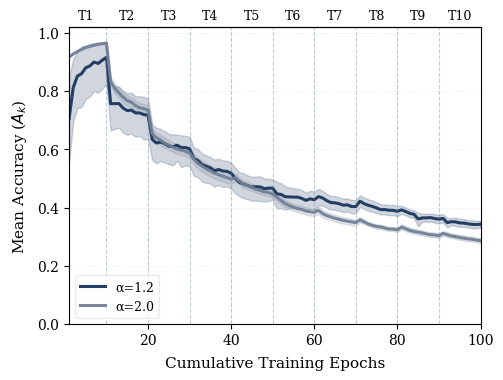


Condition       | Final Acc (95% CI)      | BWT (95% CI)           
-----------------------------------------------------------------
α=1.2           | 0.3424 [0.3306, 0.3559] | -0.6692 [-0.6988, -0.5789]
α=2.0           | 0.2863 [0.2789, 0.2973] | -0.7615 [-0.7696, -0.7490]


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import bootstrap
import re  # To safely extract seed integers from folder names

# --- Configuration ---
results_path = Path("./pmnist_fc10")
acc_threshold = 0.0
num_tasks = 10

def plot_multiple_accuracies_bootstrapped(param_pairs, n_boot=1000):
    """
    Plots the Mean Average Accuracy (Ak) with bootstrapped 95% Confidence Intervals.
    Handles randomized sequence folders formatted as folder_name_s{seed}
    """
    master_plot_data = []
    task_transition_epochs = None
    stats_summary = {} # Structure: {condition: {'acc': [], 'bwt': []}}

    for alpha, g, lr in param_pairs:
        condition_label = f"α={alpha}"
        stats_summary[condition_label] = {'acc': [], 'bwt': []}

        # Base folder naming pattern without seed suffix
        base_folder_pattern = f"alpha_{alpha}_g_{g}_lr_{lr}"

        # Find all seed folders matching this base condition name (e.g., base_name_s0, base_name_s1...)
        matching_seed_folders = list(results_path.glob(f"{base_folder_pattern}_s*"))

        if not matching_seed_folders:
            print(f"Skipping parameter set: {base_folder_pattern} (No matching seed folders found).")
            continue

        seed_count = 0

        # Iterate through every seed folder found
        for folder_path in matching_seed_folders:
            # Extract seed integer using regex to preserve the "Seed ID" for the bootstrap unit
            seed_match = re.search(r'_s(\d+)$', folder_path.name)
            if seed_match:
                seed_id = int(seed_match.group(1))
            else:
                seed_id = seed_count  # Fallback just in case

            # Since each folder corresponds to exactly one seed run, look for the internal CSV
            csv_files = list(folder_path.glob("results_log_seed_*.csv"))
            if not csv_files:
                continue

            csv_file = csv_files[0] # Grab the singular log inside this folder
            df = pd.read_csv(csv_file)

            if df["task_1_acc"].iloc[-1] < acc_threshold:
                continue

            # --- CALCULATING AGGREGATES ---
            final_row = df.iloc[-1]
            task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]
            stats_summary[condition_label]['acc'].append(final_row[task_cols].mean())

            bwt_elements = []
            for t in range(1, num_tasks):
                r_ii = df[df['task_id'] == t].iloc[-1][f"task_{t}_acc"]
                r_ni = final_row[f"task_{t}_acc"]
                bwt_elements.append(r_ni - r_ii)

            stats_summary[condition_label]['bwt'].append(sum(bwt_elements) / len(bwt_elements))
            # ------------------------------

            seed_count += 1

            # Process Epochs for Ak calculation
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_id  # Stabilizes bootstrap resamples across matching seed trajectories
                })

            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} seed folders for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    plot_df = pd.DataFrame(master_plot_data)

    # 1. 1.5x scaling logic from your setup (Width ~4.92in, Height ~3.69in)
    width, height = 3.281 * 1.5, 2.461 * 1.5

    # 2. GLOBAL STYLING OVERRIDES (Times New Roman & Spine adjustments)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 11,          # Matches 10-11pt text layout size nicely
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,       # Vectorized font safety for IEEE/Xplore systems
        "ps.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(width, height), constrained_layout=True)

    # 3. HIGH-CONTRAST ACADEMIC PALETTE
    # Maps specific color signatures directly to your Condition strings
    custom_palette = {
        "α=1.2": "#1A365D",  # Deep Indigo/Navy (Ours - Signal Tunneling)
        "α=2.0": "#718096"   # Muted Slate Grey (Baseline - Plasticity Collapse)
    }

    # 4. PLOT EXECUTION
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        palette=custom_palette,   # Uses the professional contrast palette
        errorbar=("ci", 95),
        n_boot=n_boot,
        linewidth=2.2,            # Clean vector line weight
        alpha=0.95,
        ax=ax
    )

    # 5. TRANSITION AND MARGIN HYGIENE
    if task_transition_epochs:
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            ax.axvline(x=epoch_mark, color='#718096', linestyle='--', linewidth=0.8, alpha=0.4)

    # Secondary X-Axis setup for Task Midpoints
    task_midpoints = [(task_transition_epochs[i] + task_transition_epochs[i+1])/2
                      for i in range(len(task_transition_epochs)-1)]
    first_midpoint = task_transition_epochs[0] / 2
    task_midpoints.insert(0, first_midpoint)

    secax = ax.secondary_xaxis('top')
    secax.set_xticks(task_midpoints)
    secax.set_xticklabels([f"T{i+1}" for i in range(len(task_midpoints))], fontsize=9)
    secax.tick_params(axis='x', which='both', length=0)

    # 6. BOUNDS & LABEL POLISHING
    ax.set_ylim(0, 1.02)
    ax.set_xlim(1, plot_df["Total Epoch"].max())
    ax.set_ylabel("Mean Accuracy ($A_k$)", labelpad=6)
    ax.set_xlabel("Cumulative Training Epochs", labelpad=6)

    # Grid styling
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.7)

    # Legend anchoring (placing it cleanly out of the way of the ascending plot data)
    ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="#E2E8F0")

    # Remove top and right border lines for a cleaner modern aesthetic
    sns.despine(ax=ax, top=False, right=False) # top=False preserves the secondary axis line cleanly

    plt.savefig("pmnist_acc.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    print("\n" + "="*65)
    print(f"{'Condition':<15} | {'Final Acc (95% CI)':<23} | {'BWT (95% CI)':<23}")
    print("-" * 65)
    for condition, data in stats_summary.items():
        # Convert list data to numpy arrays for scipy processing
        acc_array = np.array(data['acc'])
        bwt_array = np.array(data['bwt'])

        # Check if we have enough seed samples to bootstrap safely
        if len(acc_array) > 1:
            try:
                # 1. Bootstrap Final Average Accuracy
                res_acc = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                acc_str = f"{acc_array.mean():.4f} [{res_acc.confidence_interval.low:.4f}, {res_acc.confidence_interval.high:.4f}]"
            except Exception:
                # Fallback to percentile bootstrap if BCa encounters extreme sample variance limits
                res_acc = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                acc_str = f"{acc_array.mean():.4f} [{res_acc.confidence_interval.low:.4f}, {res_acc.confidence_interval.high:.4f}]"

            try:
                # 2. Bootstrap Backward Transfer (BWT)
                res_bwt = bootstrap((bwt_array,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                bwt_str = f"{bwt_array.mean():.4f} [{res_bwt.confidence_interval.low:.4f}, {res_bwt.confidence_interval.high:.4f}]"
            except Exception:
                res_bwt = bootstrap((bwt_array,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                bwt_str = f"{bwt_array.mean():.4f} [{res_bwt.confidence_interval.low:.4f}, {res_bwt.confidence_interval.high:.4f}]"
        else:
            # Fallback format if only 1 seed is found or processed
            acc_str = f"{acc_array.mean():.4f} [N/A]"
            bwt_str = f"{bwt_array.mean():.4f} [N/A]"

        print(f"{condition:<15} | {acc_str:<23} | {bwt_str:<23}")
    print("="*65)

# --- Execution ---
comparison_list = [
    (1.2, 1.0, 0.01),
    (2.0, 1.0, 0.01)
]

# Set n_boot to 10000 for your final publication plot!
plot_multiple_accuracies_bootstrapped(comparison_list, n_boot=10000)

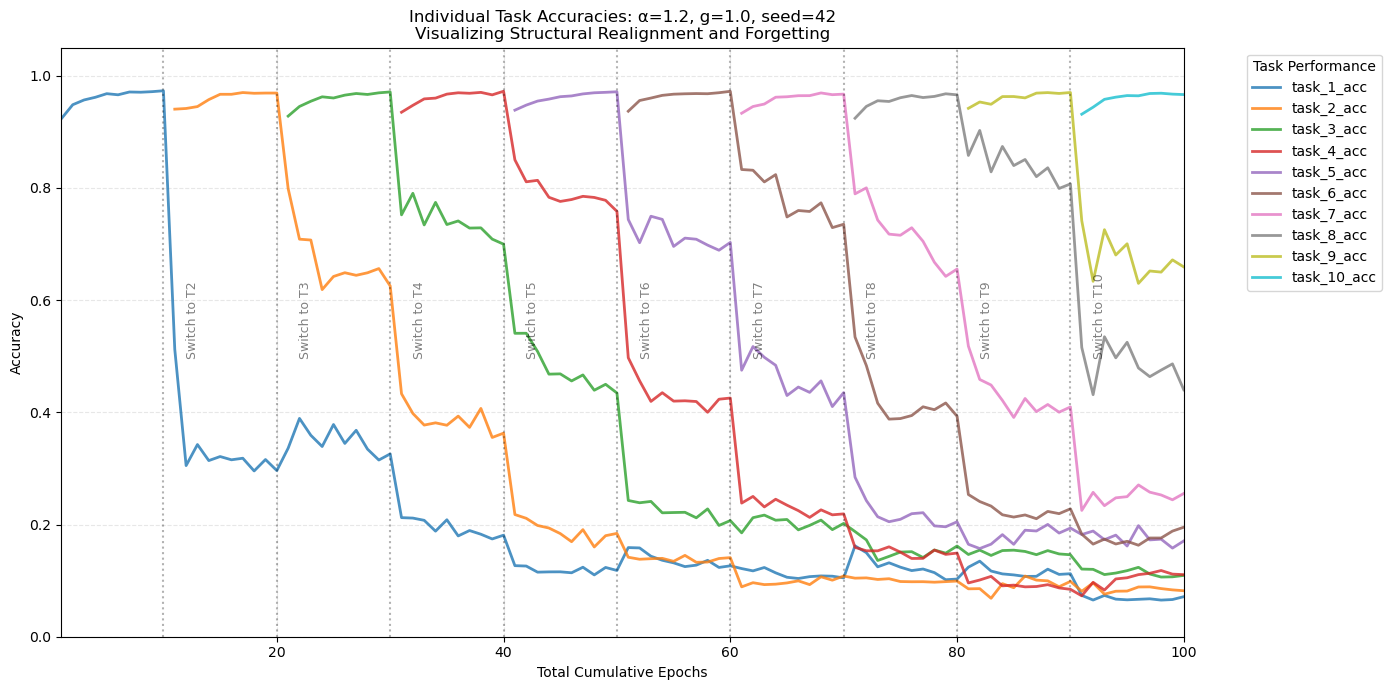

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./pmnist_fc10/")
num_tasks = 10

def plot_individual_task_curves(alpha, g, lr, seed=42):
    """
    Plots the individual task accuracy lines for a specific run.
    Helps identify the 'Warm Start' phenomenon and Catastrophic Forgetting.
    """
    folder_name = f"alpha_{alpha}_g_{g}_lr_{lr}"
    folder_path = results_path / folder_name
    csv_file = folder_path / f"results_log_seed_{seed}.csv"

    if not csv_file.exists():
        print(f"File not found: {csv_file}")
        return

    df = pd.read_csv(csv_file)

    # We need to melt the task columns into a long format for Seaborn
    # Columns are: [Total Epoch, task_1_acc, task_2_acc, ..., task_10_acc]
    task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]

    # Track the cumulative epoch index (1 to 300 for 10 tasks x 30 epochs)
    df['Cumulative Epoch'] = range(1, len(df) + 1)

    # Melt data for plotting
    plot_df = df.melt(
        id_vars=['Cumulative Epoch'],
        value_vars=task_cols,
        var_name='Task',
        value_name='Accuracy'
    )

    # --- Plotting ---
    plt.figure(figsize=(14, 7))

    # Highlight the current task learning with a thicker line
    # Older tasks will appear as decaying curves[cite: 1, 2]
    sns.lineplot(
        data=plot_df,
        x="Cumulative Epoch",
        y="Accuracy",
        hue="Task",
        palette="tab10",
        linewidth=2,
        alpha=0.8
    )

    # Capture transition points for vertical lines
    task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

    for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
        plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
        plt.text(epoch_mark + 2, 0.5, f"Switch to T{t_idx+2}",
                 fontsize=9, rotation=90, alpha=0.5)

    plt.title(f"Individual Task Accuracies: α={alpha}, g={g}, seed={seed}\n"
              f"Visualizing Structural Realignment and Forgetting")
    plt.ylim(0, 1.05)
    plt.xlim(1, len(df))
    plt.ylabel("Accuracy")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Task Performance")
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Visualize the Heavy-Tailed run to inspect Task 1 'Rich Learning' vs Task 2 'Warm Start'
plot_individual_task_curves(alpha=1.2, g=1.0, lr=0.01, seed=42)

In [6]:
import pandas as pd
import numpy as np
import torch
import re
from pathlib import Path
from scipy.stats import bootstrap

# Ensure device context is defined globally
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead[cite: 7]."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)
    return imgs, lbls

# --- Helper Functions for Metrics ---
def compute_spectral_metrics(activations):
    """
    Computes Stable Rank and Participation Ratio on pre-activations.
    activations: [Batch, Width]
    """
    # Singular values for Stable Rank
    _, s, _ = torch.svd(activations)
    s_sq = s**2
    stable_rank = s_sq.sum() / s_sq.max()

    # Eigenvalues for Participation Ratio (using singular values directly)
    pr = (s_sq.sum())**2 / (s_sq**2).sum()

    return stable_rank.item(), pr.item()

def get_weight_condition_number(model):
    """Calculates condition number (s_max / s_min) for all layers."""
    cond_nums = []
    for name, param in model.named_parameters():
        if 'weight' in name and len(param.shape) == 2:
            s = torch.linalg.svdvals(param)
            cond_nums.append((s.max() / (s.min() + 1e-8)).item())
    return np.mean(cond_nums)

# --- Main Analysis Script ---
def analyze_spectral_evolution(base_dir, alpha, g, lr, probe_data, n_boot=1000):
    """
    Crawls macro-ensemble directories for pMNIST runs, computes representation
    spectral shapes, and aggregates confidence limits via non-parametric bootstrapping.
    """
    results = []
    base_path = Path(base_dir)

    # pMNIST structural directory pattern without seed suffix
    param_str = f"alpha_{alpha}_g_{g}_lr_{lr}"
    seed_folders = list(base_path.glob(f"{param_str}_s*"))

    if not seed_folders:
        print(f"Skipping: No folders found for {param_str} in {base_dir}")
        return

    print(f"Analyzing {len(seed_folders)} seeds for {param_str}...")

    for folder in seed_folders:
        seed_match = re.search(r'_s(\d+)$', folder.name)
        seed = int(seed_match.group(1)) if seed_match else 0

        checkpoint_dir = folder / "checkpoints"
        snapshots = {
            "Start (T1)": checkpoint_dir / "snapshot_T1_E9.pt",
            "End (T10)": checkpoint_dir / "snapshot_T10_E9.pt"
        }

        for stage, path in snapshots.items():
            if not path.exists():
                continue

            # Load Weights into the global model shell
            checkpoint = torch.load(path, map_location=device)
            test_model.load_state_dict(checkpoint['state_dict'])
            test_model.eval()

            # 1. Weight Metric: Average Condition Number (\kappa)
            avg_kappa = get_weight_condition_number(test_model)

            # 2. Feature Metrics: Extract Pre-Activations
            with torch.no_grad():
                all_pre_acts = test_model.get_pre_activations(probe_data)
                # Target penultimate layer (Index 8 for 10-layer depth)
                target_h = all_pre_acts[8]

            sr, pr = compute_spectral_metrics(target_h)

            results.append({
                "Seed": seed,
                "Stage": stage,
                "Condition Number": avg_kappa,
                "Stable Rank": sr,
                "Participation Ratio": pr
            })

    df_results = pd.DataFrame(results)
    stages = ["Start (T1)", "End (T10)"]

    # --- Bootstrapping Execution & Console Format Construction ---
    print("\n" + "="*95)
    print(f"{'Stage':<12} | {'Condition Number (95% CI)':<25} | {'Stable Rank (95% CI)':<25} | {'PR (95% CI)':<20}")
    print("-" * 95)

    for stage in stages:
        stage_df = df_results[df_results["Stage"] == stage]

        if stage_df.empty:
            continue

        metrics_out = {}
        for metric in ["Condition Number", "Stable Rank", "Participation Ratio"]:
            arr = stage_df[metric].to_numpy()
            mu = arr.mean()

            if len(arr) > 1:
                try:
                    res = bootstrap((arr,), np.mean, confidence_level=0.95, method='BCa', n_resamples=n_boot)
                    metrics_out[metric] = f"{mu:.2f} [{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}]"
                except Exception:
                    # Percentile fallback protection for stable low-variance layers
                    res = bootstrap((arr,), np.mean, confidence_level=0.95, method='percentile', n_resamples=n_boot)
                    metrics_out[metric] = f"{mu:.2f} [{res.confidence_interval.low:.2f}, {res.confidence_interval.high:.2f}]"
            else:
                metrics_out[metric] = f"{mu:.2f} [N/A]"

        print(f"{stage:<12} | {metrics_out['Condition Number']:<25} | {metrics_out['Stable Rank']:<25} | {metrics_out['Participation Ratio']:<20}")
    print("="*95 + "\n")

# --- EXAMPLE USAGE ---
# 1. Define your probe batch (e.g., Task 1 Test Data)
# We use the original Task 1 permutation (Identity)
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels)]
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)))
    return perms

permutations = generate_permutations(10, seed=42)
task1_probe = test_imgs_raw[:512, permutations[0]]
test_model = GeneralMLP(784, 784, 10, 9, "tanh", bias=False).to(device)

# --- EXECUTION HARNESS CONTAINER ---
# (Assuming permutations, task1_probe, and test_model are instantiated as in your sample)
# To create your finalized publication manuscript values, switch n_boot to 10000.

print("HEAVY-TAILED MANIFOLD PROFILE (pMNIST):")
analyze_spectral_evolution("./pmnist_fc10/", alpha=1.2, g=1.0, lr=0.01, probe_data=task1_probe, n_boot=1000)

print("GAUSSIAN BASELINE PROFILE (pMNIST):")
analyze_spectral_evolution("./pmnist_fc10/", alpha=2.0, g=1.0, lr=0.01, probe_data=task1_probe, n_boot=1000)

HEAVY-TAILED MANIFOLD PROFILE (pMNIST):
Analyzing 20 seeds for alpha_1.2_g_1.0_lr_0.01...

Stage        | Condition Number (95% CI) | Stable Rank (95% CI)      | PR (95% CI)         
-----------------------------------------------------------------------------------------------
Start (T1)   | 1729608.49 [1311866.26, 2350798.94] | 1.36 [1.19, 1.67]         | 1.75 [1.41, 2.69]   
End (T10)    | 2254604.33 [1447454.00, 3898891.10] | 1.05 [1.03, 1.08]         | 1.10 [1.06, 1.16]   

GAUSSIAN BASELINE PROFILE (pMNIST):
Analyzing 20 seeds for alpha_2.0_g_1.0_lr_0.01...

Stage        | Condition Number (95% CI) | Stable Rank (95% CI)      | PR (95% CI)         
-----------------------------------------------------------------------------------------------
Start (T1)   | 6253.20 [4634.96, 9334.87] | 4.13 [4.04, 4.25]         | 6.74 [6.67, 6.81]   
End (T10)    | 21088.49 [10093.59, 49041.18] | 1.18 [1.17, 1.20]         | 1.39 [1.36, 1.43]   



Processing CKA matrices across 20 pMNIST seed runs...
 ➔ Finished computing matrix for Seed 1
 ➔ Finished computing matrix for Seed 69
 ➔ Finished computing matrix for Seed 14
 ➔ Finished computing matrix for Seed 2
 ➔ Finished computing matrix for Seed 10
 ➔ Finished computing matrix for Seed 3
 ➔ Finished computing matrix for Seed 16
 ➔ Finished computing matrix for Seed 4
 ➔ Finished computing matrix for Seed 11
 ➔ Finished computing matrix for Seed 42
 ➔ Finished computing matrix for Seed 9
 ➔ Finished computing matrix for Seed 12
 ➔ Finished computing matrix for Seed 13
 ➔ Finished computing matrix for Seed 67
 ➔ Finished computing matrix for Seed 0
 ➔ Finished computing matrix for Seed 7
 ➔ Finished computing matrix for Seed 5
 ➔ Finished computing matrix for Seed 8
 ➔ Finished computing matrix for Seed 6
 ➔ Finished computing matrix for Seed 15

Running 10000 BCa bootstrap resamples per matrix cell...


/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


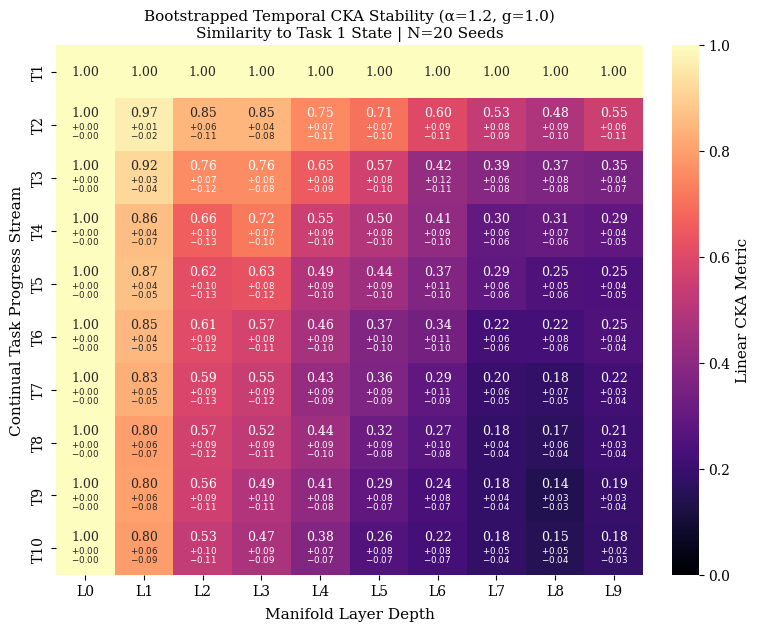

Processing CKA matrices across 20 pMNIST seed runs...
 ➔ Finished computing matrix for Seed 11
 ➔ Finished computing matrix for Seed 13
 ➔ Finished computing matrix for Seed 10
 ➔ Finished computing matrix for Seed 12
 ➔ Finished computing matrix for Seed 7
 ➔ Finished computing matrix for Seed 2
 ➔ Finished computing matrix for Seed 14
 ➔ Finished computing matrix for Seed 3
 ➔ Finished computing matrix for Seed 8
 ➔ Finished computing matrix for Seed 4
 ➔ Finished computing matrix for Seed 9
 ➔ Finished computing matrix for Seed 0
 ➔ Finished computing matrix for Seed 42
 ➔ Finished computing matrix for Seed 1
 ➔ Finished computing matrix for Seed 16
 ➔ Finished computing matrix for Seed 5
 ➔ Finished computing matrix for Seed 15
 ➔ Finished computing matrix for Seed 6
 ➔ Finished computing matrix for Seed 69
 ➔ Finished computing matrix for Seed 67

Running 10000 BCa bootstrap resamples per matrix cell...


/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


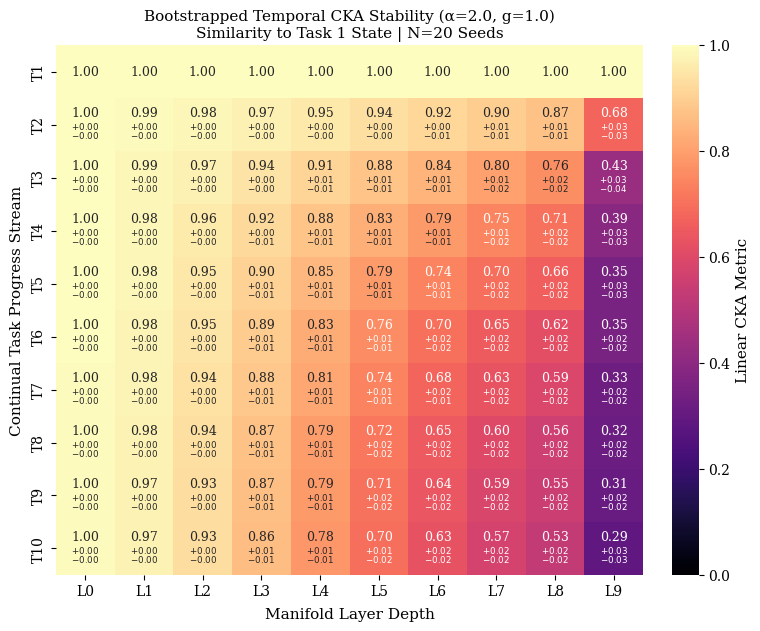

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import re
from pathlib import Path
from scipy.stats import bootstrap

# --- Configuration ---
results_root = Path("./pmnist_fc10")
num_tasks = 10
num_layers = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. CORE CKA MATHEMATICS (UNCHANGED) ---
def linear_HSIC(K, L):
    n = K.shape[0]
    H = torch.eye(n, device=K.device) - (1.0 / n)
    K_centered = H @ K @ H
    L_centered = H @ L @ H
    return torch.trace(K_centered @ L_centered) / ((n - 1) ** 2)

def compute_cka(h1, h2):
    h1, h2 = h1.float(), h2.float()
    K = h1 @ h1.T
    L = h2 @ h2.T
    hsic_kl = linear_HSIC(K, L)
    hsic_kk = linear_HSIC(K, K)
    hsic_ll = linear_HSIC(L, L)
    return (hsic_kl / torch.sqrt(hsic_kk * hsic_ll)).item()

def get_temporal_cka(model, path_t1, path_t2, probe_batch, layer_idx):
    """Computes CKA for a layer between two snapshots."""
    model.eval()

    # Snapshot 1
    snap1 = torch.load(path_t1, map_location=device)
    model.load_state_dict(snap1["state_dict"])
    with torch.no_grad():
        h1_dict = model.get_pre_activations(probe_batch)
        h1 = h1_dict["classifier"] if layer_idx == 9 else h1_dict[layer_idx]

    # Snapshot 2
    snap2 = torch.load(path_t2, map_location=device)
    model.load_state_dict(snap2["state_dict"])
    with torch.no_grad():
        h2_dict = model.get_pre_activations(probe_batch)
        h2 = h2_dict["classifier"] if layer_idx == 9 else h2_dict[layer_idx]

    return compute_cka(h1, h2)

def compile_bootstrapped_cka(alpha, g, lr_str, probe_data, model_shell, n_boot=1000, ref_task_idx=1):
    """
    Crawls your pMNIST folder layout, computes a 10x10 matrix per seed,
    and returns the 95% BCa confidence interval limits for every coordinate cell.
    """
    # FIX 1: Directory wildcard pattern updated to match "alpha_2.0_g_1.0_lr_1e-02_s7"
    base_folder_pattern = f"alpha_{alpha}_g_{g}_lr_{lr_str}"
    matching_seed_folders = list(results_root.glob(f"{base_folder_pattern}_s*"))

    if not matching_seed_folders:
        print(f"No folders found for {base_folder_pattern} inside {results_root}")
        return

    # Tensor to store raw 2D CKA matrices: [num_seeds, num_tasks, num_layers]
    all_seed_matrices = []

    print(f"Processing CKA matrices across {len(matching_seed_folders)} pMNIST seed runs...")

    for folder_path in matching_seed_folders:
        seed_match = re.search(r'_s(\d+)$', folder_path.name)
        seed_id = int(seed_match.group(1)) if seed_match else 0

        checkpoints_path = folder_path / "checkpoints"
        # FIX 2: Switched target epoch extension index from E19 to E9 to match training script parameters
        snap_ref_path = checkpoints_path / f"snapshot_T{ref_task_idx}_E9.pt"

        if not snap_ref_path.exists():
            continue

        seed_matrix = np.zeros((num_tasks, num_layers))

        for t_idx in range(num_tasks):
            curr_task = t_idx + 1
            snap_curr_path = checkpoints_path / f"snapshot_T{curr_task}_E9.pt"

            if not snap_curr_path.exists():
                continue

            for l_idx in range(num_layers):
                score = get_temporal_cka(model_shell, snap_ref_path, snap_curr_path, probe_data, l_idx)
                seed_matrix[t_idx, l_idx] = score

        all_seed_matrices.append(seed_matrix)
        print(f" ➔ Finished computing matrix for Seed {seed_id}")

    all_seed_matrices = np.array(all_seed_matrices)
    num_valid_seeds = all_seed_matrices.shape[0]

    # Containers for the final aggregated bootstrap estimates
    mean_matrix = np.zeros((num_tasks, num_layers))
    ci_lower_matrix = np.zeros((num_tasks, num_layers))
    ci_upper_matrix = np.zeros((num_tasks, num_layers))

    print(f"\nRunning {n_boot} BCa bootstrap resamples per matrix cell...")
    for t in range(num_tasks):
        for l in range(num_layers):
            cell_samples = all_seed_matrices[:, t, l]
            mean_matrix[t, l] = cell_samples.mean()

            if num_valid_seeds > 1:
                try:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
                except Exception:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
            else:
                ci_lower_matrix[t, l] = mean_matrix[t, l]
                ci_upper_matrix[t, l] = mean_matrix[t, l]

    # --- VISUALIZATION PHASE ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 9, # Tightened font size slightly to clear 10x10 grid text boundaries
        "pdf.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(7.5, 6.2), constrained_layout=True)

    # Create annotation matrix with stacked sub/superscript delta indicators
    annot_labels = np.empty_like(mean_matrix, dtype=object)
    for t in range(num_tasks):
        curr_task_num = t + 1
        for l in range(num_layers):
            m = mean_matrix[t, l]

            # FIX 3: Bypasses bootstrap math for the reference row to avoid division by zero errors
            if curr_task_num == ref_task_idx:
                annot_labels[t, l] = "1.00"
            else:
                u_delta = ci_upper_matrix[t, l] - m
                l_delta = m - ci_lower_matrix[t, l]
                u_delta = max(0.0, u_delta)
                l_delta = max(0.0, l_delta)
                annot_labels[t, l] = f"{m:.2f}\n$^{{+{u_delta:.2f}}}_{{-{l_delta:.2f}}}$"

    sns.heatmap(
        mean_matrix,
        annot=annot_labels,
        fmt="",
        cmap="magma",
        cbar_kws={'label': 'Linear CKA Metric'},
        xticklabels=[f"L{i}" for i in range(num_layers)],
        yticklabels=[f"T{i+1}" for i in range(num_tasks)],
        vmin=0.0,
        vmax=1.0,
        ax=ax
    )

    ax.set_title(f"Bootstrapped Temporal CKA Stability (α={alpha}, g={g})\nSimilarity to Task {ref_task_idx} State | N={num_valid_seeds} Seeds", fontsize=11)
    ax.set_xlabel("Manifold Layer Depth", labelpad=6)
    ax.set_ylabel("Continual Task Progress Stream", labelpad=6)

    plt.savefig(f"pmnist_cka_heatmap_alpha_{alpha}.pdf", bbox_inches="tight", dpi=300)
    plt.show()

# --- 3. RUNTIME INVOCATION BLOCK ---
# Passing your pre-permuted Identity Task 1 sample directly as the fixed probe
test_model = GeneralMLP(784, 784, 10, 9, "tanh", bias=False).to(device)

# Formatted string variable maps string literal "1e-02" directly to match folder naming structures
compile_bootstrapped_cka(alpha=1.2, g=1.0, lr_str="0.01", probe_data=task1_probe, model_shell=test_model, n_boot=10000)
compile_bootstrapped_cka(alpha=2.0, g=1.0, lr_str="0.01", probe_data=task1_probe, model_shell=test_model, n_boot=10000)

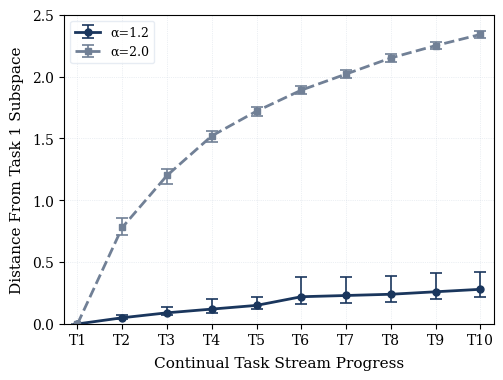

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. MANUAL DATA ENTRY ---
tasks = list(range(1, 11))

# 1. Means (Your existing display numbers)
cka_ht_mean = [0.00, 0.05, 0.09, 0.12, 0.15, 0.22, 0.23, 0.24, 0.26, 0.28]
cka_gauss_mean = [0.00, 0.78, 1.20, 1.52, 1.72, 1.89, 2.02, 2.15, 2.25, 2.34]

# 2. DELTAS: Format is [ [lower_deltas], [upper_deltas] ]
# Example values shown below. Replace with your actual calculated display deltas!
# (Note: Set Task 1 deltas to 0.0 since it is a locked reference)
ht_deltas = [
    [0.0, 0.01, 0.02, 0.03, 0.03, 0.06, 0.06, 0.06, 0.06, 0.06],  # Lower deltas (Mean - Lower Bound)
    [0.0, 0.02, 0.05, 0.08, 0.07, 0.16, 0.15, 0.15, 0.15, 0.14]   # Upper deltas (Upper Bound - Mean)
]

gauss_deltas = [
    [0.0, 0.06, 0.07, 0.05, 0.04, 0.03, 0.03, 0.03, 0.03, 0.03],  # Lower deltas
    [0.0, 0.08, 0.05, 0.04, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03]   # Upper deltas
]

# --- 2. GLOBAL PUBLICATION TYPOGRAPHY ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# 3. Figure Dimension Limits (1.5x of your standard baseline column constraints)
width, height = 3.281 * 1.5, 2.461 * 1.5
fig, ax = plt.subplots(figsize=(width, height), constrained_layout=True)

# --- 3. EXECUTION WITH ASYMMETRIC ERROR BARS ---
# Heavy-Tailed Model (Ours: Deep Indigo/Navy)
ax.errorbar(
    x=tasks, y=cka_ht_mean, yerr=ht_deltas,
    marker='o', markersize=5, linewidth=2.0, color='#1A365D',
    capsize=4, capthick=1.2, elinewidth=1.2, # error bar cap customization
    label='α=1.2'
)

# Gaussian Model (Baseline: Muted Slate Grey)
ax.errorbar(
    x=tasks, y=cka_gauss_mean, yerr=gauss_deltas,
    marker='s', markersize=5, linewidth=2.0, color='#718096', linestyle='--',
    capsize=4, capthick=1.2, elinewidth=1.2,
    label='α=2.0'
)

# --- 4. GRAPH POLISHING & SPACING ---
ax.set_ylabel("Distance From Task 1 Subspace", labelpad=6)
ax.set_xlabel("Continual Task Stream Progress", labelpad=6)

# Force strict task boundaries and labeling
ax.set_xticks(tasks)
ax.set_xticklabels([f"T{i}" for i in tasks])
ax.set_xlim(0.7, 10.3)
ax.set_ylim(0.00, 2.5)

# Grid layout rules
ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.7)

# Legend placement anchored inside the open bottom-left white space
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#E2E8F0")

# Clear bounding box spines for a modern aesthetic
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)

# Save sharp vectorized vector asset directly into your paper assets directory
plt.savefig("pmnist_grassmann.pdf", bbox_inches='tight', dpi=300)
# plt.show()

In [4]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import sys
import os
import pandas as pd
from pathlib import Path

# Verbatim references to your project structure
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROBE_EPOCHS = 30
BATCH_SIZE = 1024  # Large batch for fast GPU-preloaded probing
# Path to your physics snapshot
SNAPSHOT_PATH = Path("./results_fc10_sgd/alpha_2.0_g_1.0_lr_0.01/checkpoints/snapshot_T10_E29.pt")
OUTPUT_CSV = Path("../results/continual_learning") / "layerwise_probe_results.csv"

# Architecture params
DEPTH = 9
HIDDEN_SIZE = 784
INPUT_SIZE = 784
NUM_CLASSES = 10
BIAS = False

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# --- 2. DATA PREPARATION (GPU PRELOADING) ---
def get_gpu_loader(train=True):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    dataset = datasets.MNIST(root='../data', train=train, download=True, transform=transform)
    all_data = torch.stack([img for img, _ in dataset]).to(DEVICE)
    all_targets = torch.tensor([label for _, label in dataset]).to(DEVICE)
    return DataLoader(TensorDataset(all_data, all_targets), batch_size=BATCH_SIZE, shuffle=train)

print("Preloading MNIST to GPU...")
train_loader = get_gpu_loader(train=True)
test_loader = get_gpu_loader(train=False)

# --- 3. LOADING BACKBONE ---
model = GeneralMLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES, DEPTH, bias=BIAS).to(DEVICE)

if SNAPSHOT_PATH.exists():
    checkpoint = torch.load(SNAPSHOT_PATH, map_location=DEVICE)
    if "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        # Fallback reconstruction
        new_state_dict = {}
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
        for idx, layer in enumerate(linear_layers):
            layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
            weight_data = checkpoint["layers"][layer_key]["weights"].to(torch.float32)
            for name, param in model.named_parameters():
                if param.shape == weight_data.shape and "weight" in name and name not in new_state_dict:
                    new_state_dict[name] = weight_data
                    break
        model.load_state_dict(new_state_dict, strict=False)
    print(f"Weights loaded from: {SNAPSHOT_PATH}")
else:
    raise FileNotFoundError(f"Missing snapshot at {SNAPSHOT_PATH}")

model.eval()
for param in model.parameters():
    param.requires_grad = False

# --- 4. LAYERWISE PROBING LOOP ---
all_layer_data = []

# Get the list of pre-activations to determine depth
with torch.no_grad():
    dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
    pre_acts = model.get_pre_activations(dummy)

# Handle dictionary vs list return types from get_pre_activations
layer_keys = list(pre_acts.keys()) if isinstance(pre_acts, dict) else range(len(pre_acts))
num_layers = len(layer_keys)

for layer_idx in layer_keys:
    print(f"\n--- Probing Layer {layer_idx} ---")

    # Determine feature dimension
    with torch.no_grad():
        dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
        feature_dim = model.get_pre_activations(dummy)[layer_idx].shape[1]

    probe = nn.Linear(feature_dim, NUM_CLASSES).to(DEVICE)
    # Using SGD as requested to observe the "raw" landscape physics
    optimizer = optim.Adam(probe.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(PROBE_EPOCHS):
        probe.train()
        running_loss = 0.0

        for data, target in train_loader:
            with torch.no_grad():
                feats = model.get_pre_activations(data)[layer_idx]

            optimizer.zero_grad()
            loss = criterion(probe(feats), target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation
        probe.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                feats = model.get_pre_activations(data)[layer_idx]
                correct += probe(feats).argmax(dim=1).eq(target).sum().item()

        epoch_acc = 100. * correct / 10000
        avg_loss = running_loss / len(train_loader)

        # Capture FULL info for analysis
        all_layer_data.append({
            "layer": layer_idx,
            "epoch": epoch + 1,
            "loss": avg_loss,
            "accuracy": epoch_acc
        })

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:<10.4f} | Acc: {epoch_acc:.2f}%")

# --- 5. SAVE FULL RESULTS ---
df = pd.DataFrame(all_layer_data)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nFull trajectory saved to: {OUTPUT_CSV}")

Preloading MNIST to GPU...
Weights loaded from: results_fc10_sgd/alpha_2.0_g_1.0_lr_0.01/checkpoints/snapshot_T10_E29.pt

--- Probing Layer 0 ---
Epoch 05 | Loss: 0.2986     | Acc: 91.70%
Epoch 10 | Loss: 0.2769     | Acc: 92.16%
Epoch 15 | Loss: 0.2688     | Acc: 92.37%
Epoch 20 | Loss: 0.2634     | Acc: 92.28%
Epoch 25 | Loss: 0.2601     | Acc: 92.33%
Epoch 30 | Loss: 0.2557     | Acc: 92.39%

--- Probing Layer 1 ---
Epoch 05 | Loss: 0.2701     | Acc: 92.48%
Epoch 10 | Loss: 0.2251     | Acc: 93.41%
Epoch 15 | Loss: 0.2034     | Acc: 93.77%
Epoch 20 | Loss: 0.1876     | Acc: 94.11%
Epoch 25 | Loss: 0.1771     | Acc: 94.34%
Epoch 30 | Loss: 0.1683     | Acc: 94.46%

--- Probing Layer 2 ---
Epoch 05 | Loss: 0.2661     | Acc: 92.76%
Epoch 10 | Loss: 0.2162     | Acc: 93.76%
Epoch 15 | Loss: 0.1924     | Acc: 94.20%
Epoch 20 | Loss: 0.1760     | Acc: 94.45%
Epoch 25 | Loss: 0.1638     | Acc: 94.69%
Epoch 30 | Loss: 0.1541     | Acc: 94.88%

--- Probing Layer 3 ---
Epoch 05 | Loss: 0.2670

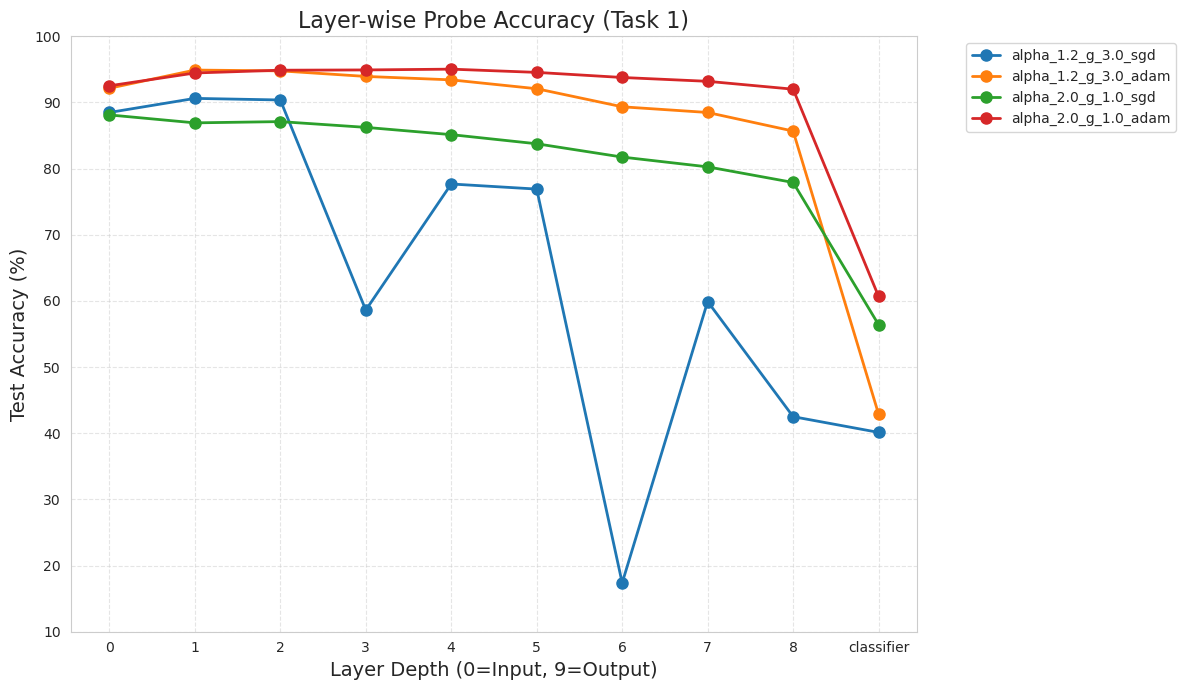

In [15]:
import pandas as pd
from pathlib import Path

# --- 1. SELECTION ---
# Add or remove filenames from this list to compare different runs
files_to_plot = [
    "layerwise_probe_results_alpha_1.2_g_3.0_sgd.csv",
    "layerwise_probe_results_alpha_1.2_g_3.0_adam.csv",
    #"layerwise_probe_results_alpha_2.0_g_3.0_sgd.csv",
    #"layerwise_probe_results_alpha_2.0_g_3.0_adam.csv",
    "layerwise_probe_results_alpha_2.0_g_1.0_sgd.csv",
    "layerwise_probe_results_alpha_2.0_g_1.0_adam.csv"
]

base_path = Path("../results/continual_learning")

# --- 2. PLOTTING ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

for file_name in files_to_plot:
    path = base_path / file_name
    if not path.exists():
        print(f"Skipping {file_name}: File not found.")
        continue

    df = pd.read_csv(path)

    # We want to plot the FINAL accuracy achieved at each layer
    # after the probe has finished its epochs
    final_accs = df.groupby("layer")["accuracy"].max().reset_index()

    # Extract metadata from filename for cleaner labeling
    label = file_name.replace("layerwise_probe_results_", "").replace(".csv", "")

    plt.plot(final_accs["layer"], final_accs["accuracy"],
             marker='o', label=label, linewidth=2, markersize=8)

# --- 3. REFINING ---
plt.title("Layer-wise Probe Accuracy (Task 1)", fontsize=16)
plt.xlabel("Layer Depth (0=Input, 9=Output)", fontsize=14)
plt.ylabel("Test Accuracy (%)", fontsize=14)
plt.ylim(10, 100)
plt.xticks(range(10))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(base_path / "layerwise_probe_comparison.pdf", bbox_inches='tight')
plt.show()

<>:76: SyntaxWarning: invalid escape sequence '\k'
<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\k'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_116350/3305179627.py:76: SyntaxWarning: invalid escape sequence '\k'
  axes[2].set_title("Condition Number ($\kappa$)\n(Higher = More Rugged/Curved)")
/tmp/ipykernel_116350/3305179627.py:77: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_ylabel("$\sigma_{max} / \sigma_{min}$ (Log Scale)")


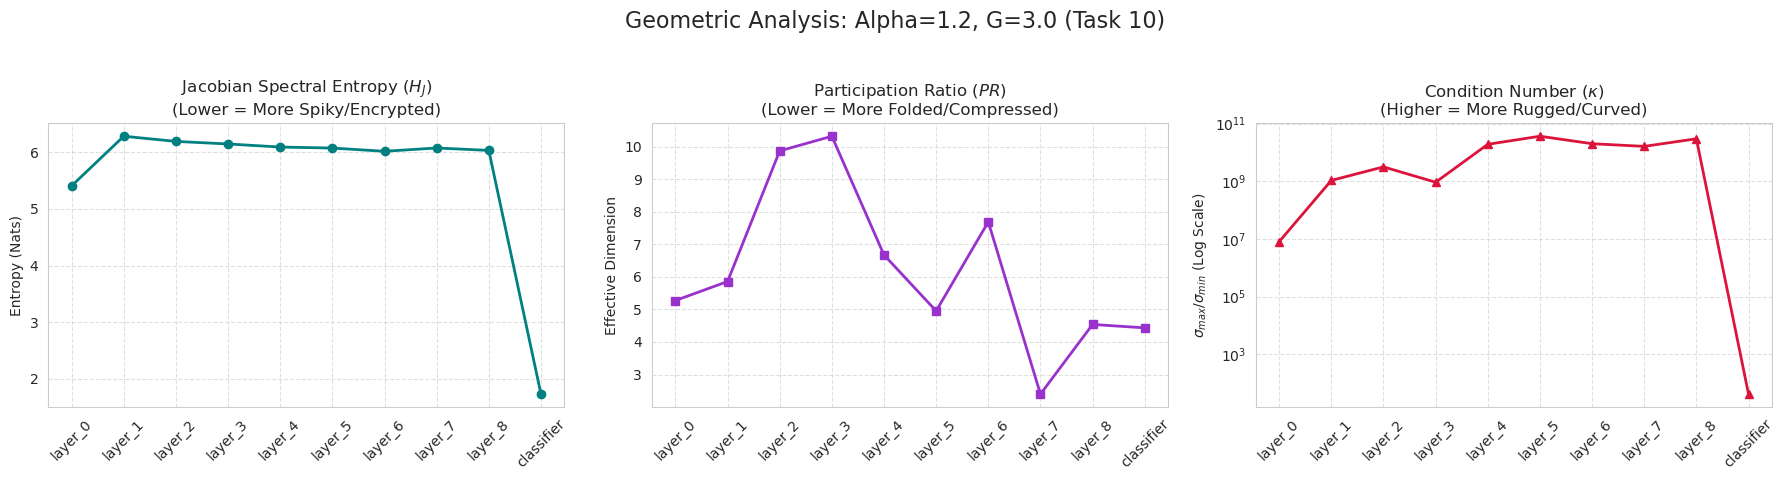

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. CONFIGURATION ---
# Point this to the snapshot you want to analyze
SNAPSHOT_FILE = Path("./results_fc10_sgd/alpha_1.2_g_3.0_lr_0.01/checkpoints/snapshot_T10_E29.pt")

def analyze_geometry(snapshot_path):
    checkpoint = torch.load(snapshot_path, map_location='cpu')
    physics_data = checkpoint['physics']
    metadata = checkpoint['metadata']

    layers = []
    entropy_list = []
    pr_list = []
    cond_list = []

    # Iterate through layers in order
    # Layer keys are usually 'layer_0', 'layer_1' ... 'classifier'
    sorted_keys = sorted(physics_data.keys(), key=lambda x: int(x.split('_')[1]) if 'layer' in x else 99)

    for key in sorted_keys:
        # Load physics tensors
        h = physics_data[key]['pre_activations']  # [Batch, Hidden]
        J = physics_data[key]['jacobian']         # [Out, In]

        # --- A. Jacobian Spectral Entropy (H_j) ---
        # Get singular values of the Jacobian
        s = torch.linalg.svdvals(J)
        s = s[s > 1e-10]  # Filter numerical noise
        p = s / s.sum()
        entropy = -torch.sum(p * torch.log(p)).item()

        # --- B. Participation Ratio (PR) ---
        # Measure dimensionality of the pre-activation manifold
        # Covariance matrix of h
        h_centered = h - h.mean(dim=0)
        cov = (h_centered.T @ h_centered) / (h.shape[0] - 1)
        eigvals = torch.linalg.eigvalsh(cov)
        eigvals = eigvals[eigvals > 0] # Filter noise
        pr = (eigvals.sum()**2 / (eigvals**2).sum()).item()

        # --- C. Condition Number (Kappa) ---
        # Measure landscape ruggedness/ill-conditioning
        cond = (s.max() / s.min()).item()

        layers.append(key)
        entropy_list.append(entropy)
        pr_list.append(pr)
        cond_list.append(cond)

    return layers, entropy_list, pr_list, cond_list, metadata

# --- 2. EXECUTION & PLOTTING ---
layers, entropy, pr, cond, meta = analyze_geometry(SNAPSHOT_FILE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Geometric Analysis: Alpha={meta['alpha']}, G={meta['g']} (Task {meta['task']})", fontsize=16)

# Plot Spectral Entropy
axes[0].plot(layers, entropy, marker='o', color='teal', linewidth=2)
axes[0].set_title("Jacobian Spectral Entropy ($H_J$)\n(Lower = More Spiky/Encrypted)")
axes[0].set_ylabel("Entropy (Nats)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Participation Ratio
axes[1].plot(layers, pr, marker='s', color='darkorchid', linewidth=2)
axes[1].set_title("Participation Ratio ($PR$)\n(Lower = More Folded/Compressed)")
axes[1].set_ylabel("Effective Dimension")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot Condition Number (Log Scale)
axes[2].semilogy(layers, cond, marker='^', color='crimson', linewidth=2)
axes[2].set_title("Condition Number ($\kappa$)\n(Higher = More Rugged/Curved)")
axes[2].set_ylabel("$\sigma_{max} / \sigma_{min}$ (Log Scale)")
axes[2].grid(True, linestyle='--', alpha=0.6)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(Path("../results/continual_learning") / f"geometry_analysis_alpha_{meta['alpha']}_g_{meta['g']}_task.pdf", bbox_inches='tight')
plt.show()

Processing Grassmann matrices across 20 seed trajectories...
 ➔ Finished computing subspaces for Seed 1
 ➔ Finished computing subspaces for Seed 69
 ➔ Finished computing subspaces for Seed 14
 ➔ Finished computing subspaces for Seed 2
 ➔ Finished computing subspaces for Seed 10
 ➔ Finished computing subspaces for Seed 3
 ➔ Finished computing subspaces for Seed 16
 ➔ Finished computing subspaces for Seed 4
 ➔ Finished computing subspaces for Seed 11
 ➔ Finished computing subspaces for Seed 42
 ➔ Finished computing subspaces for Seed 9
 ➔ Finished computing subspaces for Seed 12
 ➔ Finished computing subspaces for Seed 13
 ➔ Finished computing subspaces for Seed 67
 ➔ Finished computing subspaces for Seed 0
 ➔ Finished computing subspaces for Seed 7
 ➔ Finished computing subspaces for Seed 5
 ➔ Finished computing subspaces for Seed 8
 ➔ Finished computing subspaces for Seed 6
 ➔ Finished computing subspaces for Seed 15

Running 10000 BCa bootstrap cell-wise calculations...


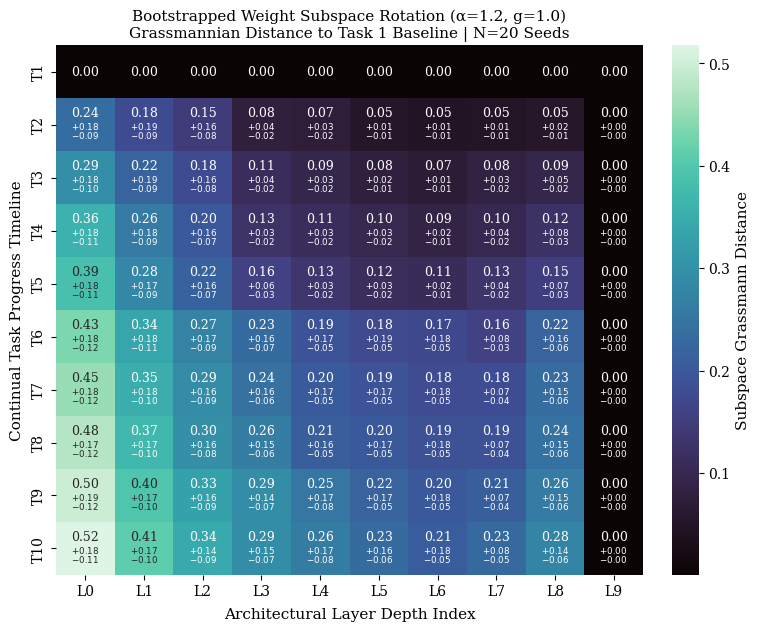

Processing Grassmann matrices across 20 seed trajectories...
 ➔ Finished computing subspaces for Seed 11
 ➔ Finished computing subspaces for Seed 13
 ➔ Finished computing subspaces for Seed 10
 ➔ Finished computing subspaces for Seed 12
 ➔ Finished computing subspaces for Seed 7
 ➔ Finished computing subspaces for Seed 2
 ➔ Finished computing subspaces for Seed 14
 ➔ Finished computing subspaces for Seed 3
 ➔ Finished computing subspaces for Seed 8
 ➔ Finished computing subspaces for Seed 4
 ➔ Finished computing subspaces for Seed 9
 ➔ Finished computing subspaces for Seed 0
 ➔ Finished computing subspaces for Seed 42
 ➔ Finished computing subspaces for Seed 1
 ➔ Finished computing subspaces for Seed 16
 ➔ Finished computing subspaces for Seed 5
 ➔ Finished computing subspaces for Seed 15
 ➔ Finished computing subspaces for Seed 6
 ➔ Finished computing subspaces for Seed 69
 ➔ Finished computing subspaces for Seed 67

Running 10000 BCa bootstrap cell-wise calculations...


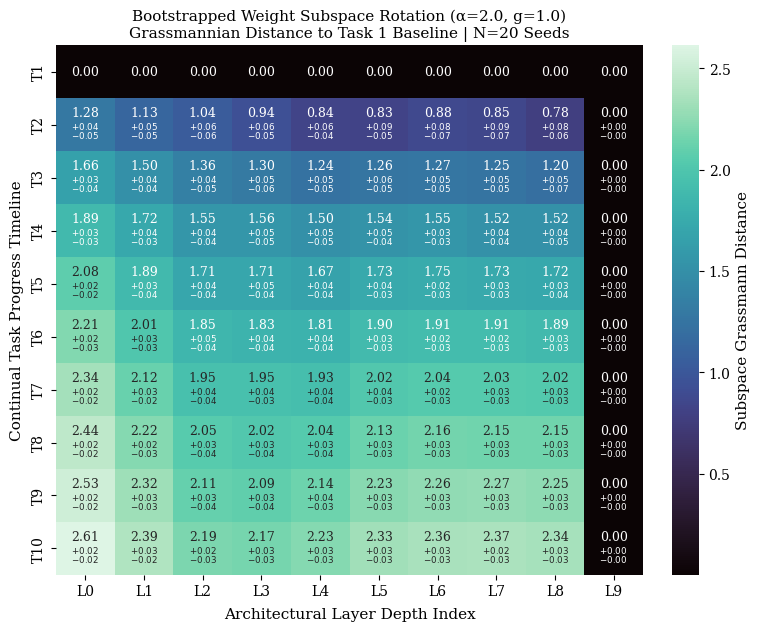

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import re
from pathlib import Path
from scipy.stats import bootstrap

# --- Configuration ---
results_root = Path("./pmnist_fc10")
num_tasks = 10
num_layers = 10
K_DIM = 50  # Rank of tracked subspace (top 50 singular vectors)

# --- 1. CORE GRAPH GEOMETRY MATHEMATICS ---
def get_top_singular_vectors(weight_matrix, k):
    """Performs SVD and returns the top k left singular vectors (U)."""
    # Ensures k does not exceed layer dimension boundaries
    k = min(k, weight_matrix.shape[0], weight_matrix.shape[1])
    U, _, _ = torch.linalg.svd(weight_matrix, full_matrices=False)
    return U[:, :k]

def calculate_grassmann_distance(U1, U2):
    """Calculates the Grassmannian distance between two k-dimensional subspaces."""
    # Principal angles are singular values of U1.T @ U2
    mat = torch.matmul(U1.t(), U2)
    cos_sq = torch.linalg.svdvals(mat)**2
    k = U1.shape[1]
    dist_sq = k - torch.sum(cos_sq)
    return torch.sqrt(torch.clamp(dist_sq, min=0.0)).item()

# --- 2. MACRO-ENSEMBLE BOOTSTRAP EXECUTOR ---
def compile_bootstrapped_grassmann(alpha, g, lr_str, n_boot=1000, ref_task_idx=1):
    """
    Crawls your pMNIST folder layout, computes a 10x10 Grassmann matrix per seed,
    and returns the 95% BCa confidence limits for subspace drift over time.
    """
    base_folder_pattern = f"alpha_{alpha}_g_{g}_lr_{lr_str}"
    matching_seed_folders = list(results_root.glob(f"{base_folder_pattern}_s*"))

    if not matching_seed_folders:
        print(f"No folders found matching {base_folder_pattern} in {results_root}")
        return

    # Tensor to store raw 2D Grassmann matrices: [num_seeds, num_tasks, num_layers]
    all_seed_matrices = []

    print(f"Processing Grassmann matrices across {len(matching_seed_folders)} seed trajectories...")

    for folder_path in matching_seed_folders:
        seed_match = re.search(r'_s(\d+)$', folder_path.name)
        seed_id = int(seed_match.group(1)) if seed_match else 0

        checkpoints_path = folder_path / "checkpoints"
        snap_ref_path = checkpoints_path / f"snapshot_T{ref_task_idx}_E9.pt"

        if not snap_ref_path.exists():
            continue

        ref_snap = torch.load(snap_ref_path, map_location='cpu')
        seed_matrix = np.zeros((num_tasks, num_layers))

        for t_idx in range(num_tasks):
            curr_task = t_idx + 1
            snap_curr_path = checkpoints_path / f"snapshot_T{curr_task}_E9.pt"

            if not snap_curr_path.exists():
                continue

            curr_snap = torch.load(snap_curr_path, map_location='cpu')

            for l_idx in range(num_layers):
                # Adaptive key handling for structural protection
                if l_idx == 9:
                    layer_key = "classifier.weight"
                else:
                    layer_key = f"features.{l_idx*2}.weight"
                    if layer_key not in ref_snap["state_dict"]:
                        layer_key = f"layers.{l_idx}.weight"  # Fallback format

                w_ref = ref_snap["state_dict"][layer_key].float()
                w_curr = curr_snap["state_dict"][layer_key].float()

                # Extract subspaces and calculate directional distance
                U_ref = get_top_singular_vectors(w_ref, K_DIM)
                U_curr = get_top_singular_vectors(w_curr, K_DIM)

                seed_matrix[t_idx, l_idx] = calculate_grassmann_distance(U_ref, U_curr)

        all_seed_matrices.append(seed_matrix)
        print(f" ➔ Finished computing subspaces for Seed {seed_id}")

    all_seed_matrices = np.array(all_seed_matrices)
    num_valid_seeds = all_seed_matrices.shape[0]

    # Containers for the final aggregated bootstrap estimates
    mean_matrix = np.zeros((num_tasks, num_layers))
    ci_lower_matrix = np.zeros((num_tasks, num_layers))
    ci_upper_matrix = np.zeros((num_tasks, num_layers))

    print(f"\nRunning {n_boot} BCa bootstrap cell-wise calculations...")
    for t in range(num_tasks):
        for l in range(num_layers):
            cell_samples = all_seed_matrices[:, t, l]
            mean_matrix[t, l] = cell_samples.mean()

            if num_valid_seeds > 1:
                try:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
                except Exception:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
            else:
                ci_lower_matrix[t, l] = mean_matrix[t, l]
                ci_upper_matrix[t, l] = mean_matrix[t, l]

    # --- VISUALIZATION PHASE ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 9,
        "pdf.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(7.5, 6.2), constrained_layout=True)

    # Compile Method 3 formatted string labels
    annot_labels = np.empty_like(mean_matrix, dtype=object)
    for t in range(num_tasks):
        curr_task_num = t + 1
        for l in range(num_layers):
            m = mean_matrix[t, l]

            if curr_task_num == ref_task_idx:
                annot_labels[t, l] = "0.00"
            else:
                u_delta = ci_upper_matrix[t, l] - m
                l_delta = m - ci_lower_matrix[t, l]
                u_delta = max(0.0, u_delta)
                l_delta = max(0.0, l_delta)
                annot_labels[t, l] = f"{m:.2f}\n$^{{+{u_delta:.2f}}}_{{-{l_delta:.2f}}}$"

    # Use 'mako' or 'rocket' to visually differentiate Grassmann distance from CKA
    sns.heatmap(
        mean_matrix,
        annot=annot_labels,
        fmt="",
        cmap="mako",
        cbar_kws={'label': 'Subspace Grassmann Distance'},
        xticklabels=[f"L{i}" for i in range(num_layers)],
        yticklabels=[f"T{i+1}" for i in range(num_tasks)],
        ax=ax
    )

    ax.set_title(f"Bootstrapped Weight Subspace Rotation (α={alpha}, g={g})\nGrassmannian Distance to Task {ref_task_idx} Baseline | N={num_valid_seeds} Seeds", fontsize=11)
    ax.set_xlabel("Architectural Layer Depth Index", labelpad=6)
    ax.set_ylabel("Continual Task Progress Timeline", labelpad=6)

    plt.savefig(f"pmnist_grassmann_heatmap_alpha_{alpha}.pdf", bbox_inches="tight", dpi=300)
    plt.show()

# --- 3. RUNTIME INVOCATION BLOCK ---
# Change n_boot to 10000 to construct your definitive publication graphics.
compile_bootstrapped_grassmann(alpha=1.2, g=1.0, lr_str="0.01", n_boot=10000)
compile_bootstrapped_grassmann(alpha=2.0, g=1.0, lr_str="0.01", n_boot=10000)